# Laboratorio 3 - Deep Learning (Reconocimiento de señas ASL)


In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from pathlib import Path

torch.manual_seed(0)
np.random.seed(0)
BASE = Path("..")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


## 1. Datos

Se regeneran los splits desde `src/preparar_datos.py`, que lee el zip, submuestrea 500 imágenes por
clase, las redimensiona a 64x64 y arma un split estratificado 70/15/15.

In [2]:
%run ../src/preparar_datos.py

clases: 29
train/val/test: 10150 2175 2175
shape imagen: (64, 64, 3)
metadata: C:\Users\VICTUS\Desktop\8vo Semestre\Data\Lab 3\laboratorio3_ds\data\processed\metadata.json


In [3]:
def cargar(split):
    X = np.load(BASE / f"data/processed/X_{split}.npy")
    y = np.load(BASE / f"data/processed/y_{split}.npy")
    return X, y

Xtr, ytr = cargar("train")
Xva, yva = cargar("val")
Xte, yte = cargar("test")
clases = np.load(BASE / "data/processed/clases.npy")
print("train:", Xtr.shape, "val:", Xva.shape, "test:", Xte.shape)
print("clases:", list(clases))

train: (10150, 64, 64, 3) val: (2175, 64, 64, 3) test: (2175, 64, 64, 3)
clases: [np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('H'), np.str_('I'), np.str_('J'), np.str_('K'), np.str_('L'), np.str_('M'), np.str_('N'), np.str_('O'), np.str_('P'), np.str_('Q'), np.str_('R'), np.str_('S'), np.str_('T'), np.str_('U'), np.str_('V'), np.str_('W'), np.str_('X'), np.str_('Y'), np.str_('Z'), np.str_('del'), np.str_('nothing'), np.str_('space')]


## 2. Análisis exploratorio

Distribución de clases (el submuestreo deja el dataset balanceado) y ejemplos de las imágenes.

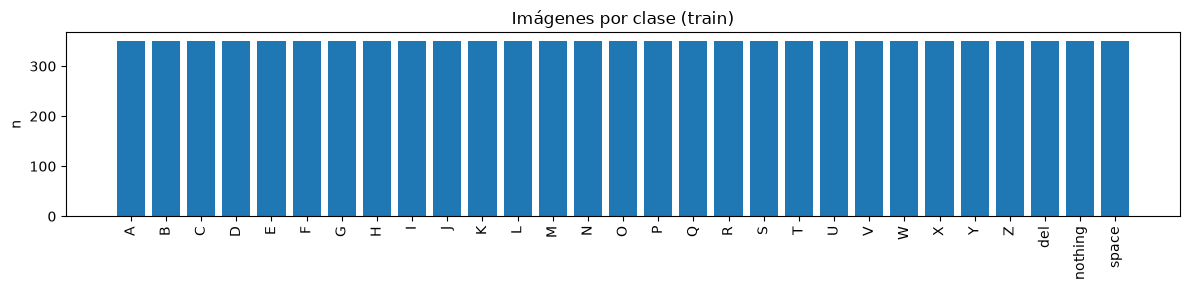

In [4]:
vals, cnts = np.unique(ytr, return_counts=True)
plt.figure(figsize=(12, 3))
plt.bar([clases[v] for v in vals], cnts)
plt.title("Imágenes por clase (train)")
plt.ylabel("n")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

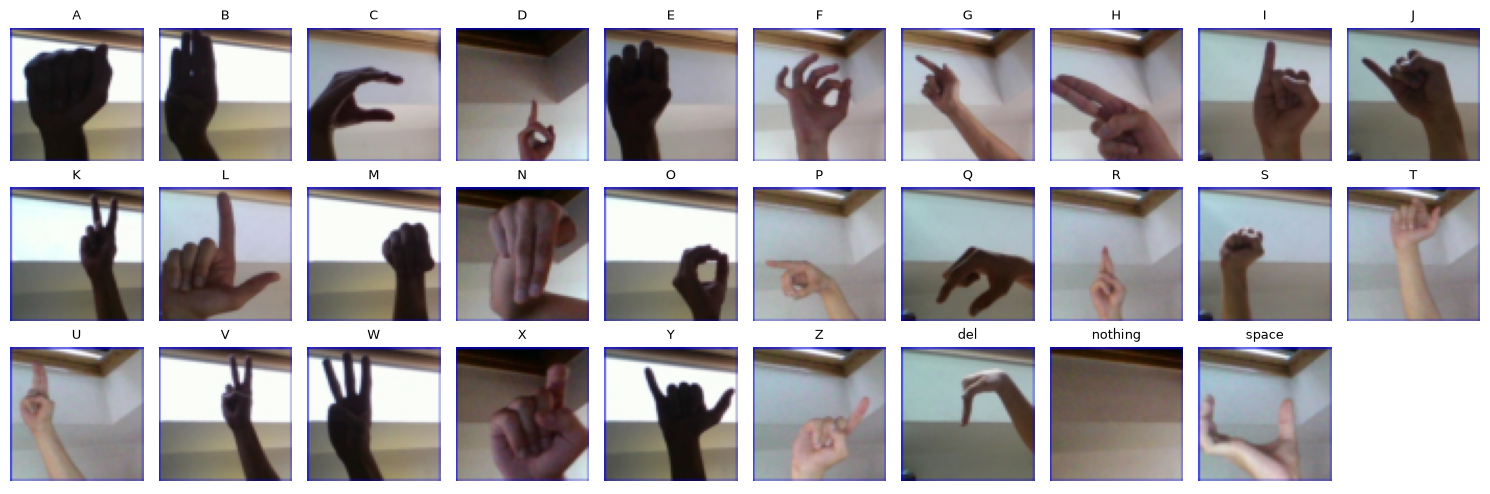

In [5]:
# una imagen de ejemplo por clase
fig, axes = plt.subplots(3, 10, figsize=(15, 5))
for ax, c in zip(axes.ravel(), range(len(clases))):
    i = np.where(ytr == c)[0][0]
    ax.imshow(Xtr[i])
    ax.set_title(clases[c], fontsize=9)
    ax.axis("off")
for ax in axes.ravel()[len(clases):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

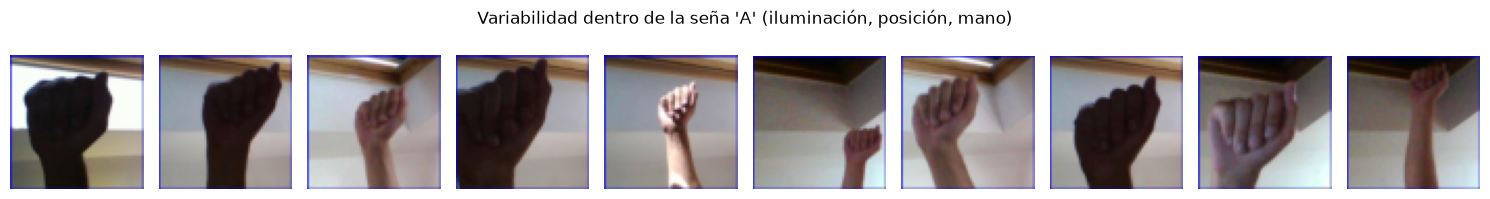

In [6]:
# variabilidad dentro de una misma seña (varios ejemplos de la letra A)
c = int(np.where(clases == "A")[0][0])
idx = np.where(ytr == c)[0][:10]
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for ax, i in zip(axes, idx):
    ax.imshow(Xtr[i]); ax.axis("off")
fig.suptitle("Variabilidad dentro de la seña 'A' (iluminación, posición, mano)")
plt.tight_layout()
plt.show()

### Letras visualmente similares

Algunas señas del alfabeto ASL comparten forma de mano y solo cambian por detalles del pulgar o la
orientación, así que es esperable que el modelo las confunda:

- **M / N / S / T**: puño cerrado, el pulgar cambia de posición entre los dedos.
- **A / E / S**: mano cerrada, diferencias sutiles en el pulgar.
- **R / U / V**: dos dedos extendidos, cambia si están juntos, cruzados o separados.
- **D / F / I**: un dedo distinto extendido sobre una mano cerrada.
- **K / V** y **G / H**: orientación parecida.

Estas confusiones se revisan más abajo con la matriz de confusión del mejor modelo.

## 3. Preprocesamiento

Las imágenes originales de 200x200 se redujeron a **64x64 RGB** para disminuir el costo sin perder
la forma general de la mano. Se almacenaron como `uint8 (N,64,64,3)` y cada lote se convirtió a
`float (N,3,64,64)` normalizado a `[0,1]` durante el entrenamiento. No se aplicaron filtros que
eliminaran color o contornos antes de las redes; Random Forest sí utilizó una versión gris 16x16.

In [7]:
def a_tensor(X, y):
    Xt = torch.tensor(X, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0
    yt = torch.tensor(y, dtype=torch.long)
    return TensorDataset(Xt, yt)

ds_tr, ds_va, ds_te = a_tensor(Xtr, ytr), a_tensor(Xva, yva), a_tensor(Xte, yte)
dl_tr = DataLoader(ds_tr, batch_size=64, shuffle=True)
dl_va = DataLoader(ds_va, batch_size=128)
dl_te = DataLoader(ds_te, batch_size=128)

## 4. Modelos CNN y tuneo

CNN parametrizable: se varía el número de bloques convolucionales, el ancho (filtros base) y el
dropout. Cada bloque es `conv 3x3 -> ReLU -> maxpool`. Se entrena con Adam y se compara la exactitud
sobre validación.

In [8]:
class CNN(nn.Module):
    def __init__(self, n_clases, bloques=2, base=16, dropout=0.25):
        super().__init__()
        capas, ch = [], 3
        for b in range(bloques):
            out = base * (2 ** b)
            capas += [nn.Conv2d(ch, out, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)]
            ch = out
        self.conv = nn.Sequential(*capas)
        lado = 64 // (2 ** bloques)  # tamaño espacial tras los maxpool
        self.cabeza = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(ch * lado * lado, 128), nn.ReLU(),
            nn.Linear(128, n_clases))

    def forward(self, x):
        return self.cabeza(self.conv(x))

In [9]:
def evaluar(modelo, dl):
    modelo.eval()
    ok = tot = 0
    with torch.no_grad():
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            pred = modelo(xb).argmax(1)
            ok += (pred == yb).sum().item()
            tot += len(yb)
    return ok / tot


def entrenar(cfg, epochs=8):
    torch.manual_seed(0)
    modelo = CNN(len(clases), **cfg).to(device)
    opt = torch.optim.Adam(modelo.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    for _ in range(epochs):
        modelo.train()
        for xb, yb in dl_tr:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss_fn(modelo(xb), yb).backward()
            opt.step()
    return modelo, evaluar(modelo, dl_va)

In [10]:
grilla = [
    dict(bloques=2, base=16, dropout=0.25),
    dict(bloques=3, base=16, dropout=0.25),
    dict(bloques=3, base=32, dropout=0.30),
    dict(bloques=4, base=32, dropout=0.40),
]

modelos, filas = {}, []
for cfg in grilla:
    modelo, acc = entrenar(cfg)
    modelos[tuple(cfg.values())] = modelo
    filas.append({**cfg, "val_acc": round(acc, 4)})
    print(cfg, "-> val_acc:", round(acc, 4))

{'bloques': 2, 'base': 16, 'dropout': 0.25} -> val_acc: 0.7982


{'bloques': 3, 'base': 16, 'dropout': 0.25} -> val_acc: 0.8474


{'bloques': 3, 'base': 32, 'dropout': 0.3} -> val_acc: 0.9122


{'bloques': 4, 'base': 32, 'dropout': 0.4} -> val_acc: 0.9218


In [11]:
import pandas as pd
tabla = pd.DataFrame(filas).sort_values("val_acc", ascending=False).reset_index(drop=True)
print(tabla.to_string(index=False))

 bloques  base  dropout  val_acc
       4    32     0.40   0.9218
       3    32     0.30   0.9122
       3    16     0.25   0.8474
       2    16     0.25   0.7982


## 5. Mejor modelo y evaluación en test

Se toma el modelo con mayor exactitud en validación y se mide sobre el conjunto de prueba (que no se
usó para elegir).

In [12]:
mejor_cfg = tabla.iloc[0][["bloques", "base", "dropout"]].to_dict()
mejor_cfg = {k: (int(v) if k != "dropout" else float(v)) for k, v in mejor_cfg.items()}
mejor = modelos[tuple(mejor_cfg.values())]
test_acc = evaluar(mejor, dl_te)
print("mejor config:", mejor_cfg)
print("test_acc:", round(test_acc, 4))

mejor config: {'bloques': 4, 'base': 32, 'dropout': 0.4}
test_acc: 0.9163


### Matriz de confusión

Para ver si las confusiones caen en las letras visualmente similares señaladas en el EDA.

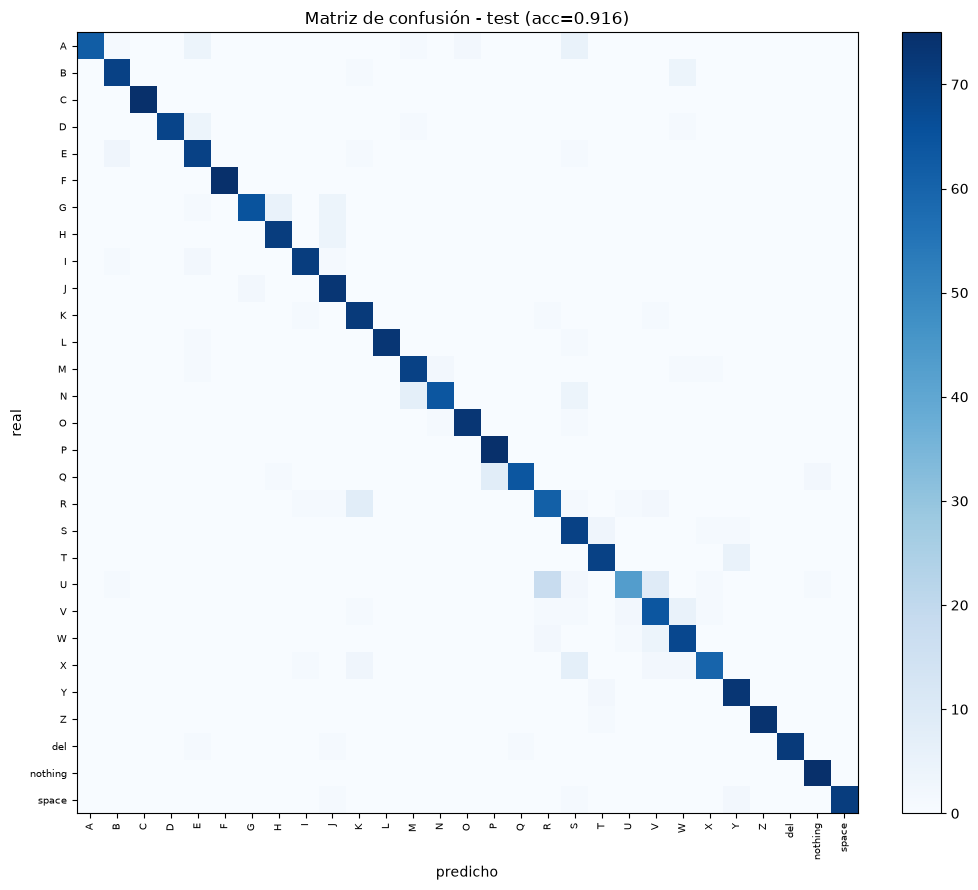

In [13]:
from sklearn.metrics import confusion_matrix

mejor.eval()
preds = []
with torch.no_grad():
    for xb, _ in dl_te:
        preds.append(mejor(xb.to(device)).argmax(1).cpu().numpy())
preds = np.concatenate(preds)

cm = confusion_matrix(yte, preds)
plt.figure(figsize=(10, 9))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(len(clases)), clases, rotation=90, fontsize=7)
plt.yticks(range(len(clases)), clases, fontsize=7)
plt.xlabel("predicho"); plt.ylabel("real")
plt.title(f"Matriz de confusión - test (acc={test_acc:.3f})")
plt.colorbar(fraction=0.046)
plt.tight_layout()
plt.show()

In [14]:
# pares más confundidos (fuera de la diagonal)
cm2 = cm.copy()
np.fill_diagonal(cm2, 0)
pares = []
for i in range(len(clases)):
    for j in range(len(clases)):
        if cm2[i, j] > 0:
            pares.append((cm2[i, j], clases[i], clases[j]))
pares.sort(reverse=True)
print("Top confusiones (real -> predicho):")
for n, r, p in pares[:10]:
    print(f"  {r} -> {p}: {n}")

Top confusiones (real -> predicho):
  U -> R: 18
  U -> V: 9
  R -> K: 8
  Q -> P: 8
  X -> S: 7
  N -> M: 7
  V -> W: 5
  T -> Y: 5
  G -> H: 5
  A -> S: 5


## 6. Red neuronal simple (fully-connected)

Como baseline de Deep Learning se usa una red densa que aplana los 12,288 píxeles de cada imagen.
A diferencia de una CNN, no comparte pesos ni conserva vecindades espaciales; por eso requiere más
parámetros y se espera que generalice peor ante traslaciones pequeñas. Se prueban dos configuraciones
y se elige únicamente con *accuracy* de validación.


In [15]:
import sys

SRC = (BASE / "src").resolve()
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from modelos import (
    CNN as CNNModular,
    RedDensa,
    ajustar_random_forest,
    crear_dataloader,
    entrenar_modelo,
    evaluar_fotos_propias,
    evaluar_fotos_random_forest,
    evaluar_fotos_random_forest,
    features_clasicas,
    fijar_semilla,
    guardar_checkpoint,
    metricas_clasificacion,
    predecir_pytorch,
)

# Carga perezosa: cada batch se convierte de uint8 a float [0,1] al usarse.
dl_tr_lazy = crear_dataloader(Xtr, ytr, batch_size=64, barajar=True)
dl_va_lazy = crear_dataloader(Xva, yva, batch_size=128)
dl_te_lazy = crear_dataloader(Xte, yte, batch_size=128)


In [16]:
configs_densas = [
    dict(ocultas=(256, 128), dropout=0.30),
    dict(ocultas=(512, 256), dropout=0.45),
]

resultados_densos, filas_densas = {}, []
for cfg in configs_densas:
    fijar_semilla(0)
    red = RedDensa(len(clases), **cfg)
    resultado = entrenar_modelo(
        red, dl_tr_lazy, dl_va_lazy, device, epochs=10, lr=1e-3, paciencia=3
    )
    clave = (cfg["ocultas"], cfg["dropout"])
    resultados_densos[clave] = resultado
    filas_densas.append({**cfg, "val_acc": resultado.mejor_val_acc})

tabla_densa = (
    pd.DataFrame(filas_densas).sort_values("val_acc", ascending=False).reset_index(drop=True)
)
tabla_densa


epoca 01 | train_acc=0.0419 | val_acc=0.0575


epoca 02 | train_acc=0.0550 | val_acc=0.0832


epoca 03 | train_acc=0.0657 | val_acc=0.0759


epoca 04 | train_acc=0.0633 | val_acc=0.0749


epoca 05 | train_acc=0.0732 | val_acc=0.1154


...

epoca 07 | train_acc=0.0553 | val_acc=0.0869


epoca 08 | train_acc=0.0601 | val_acc=0.0943


epoca 09 | train_acc=0.0649 | val_acc=0.1007


epoca 10 | train_acc=0.0636 | val_acc=0.0984


,ocultas,dropout,val_acc
0,"(256, 128)",0.30,0.146207
1,"(512, 256)",0.45,0.100690


mejor configuración densa: {'ocultas': (256, 128), 'dropout': 0.3}
métricas test: {'accuracy': 0.1389, 'precision_macro': 0.1075, 'recall_macro': 0.1389, 'f1_macro': 0.0786}


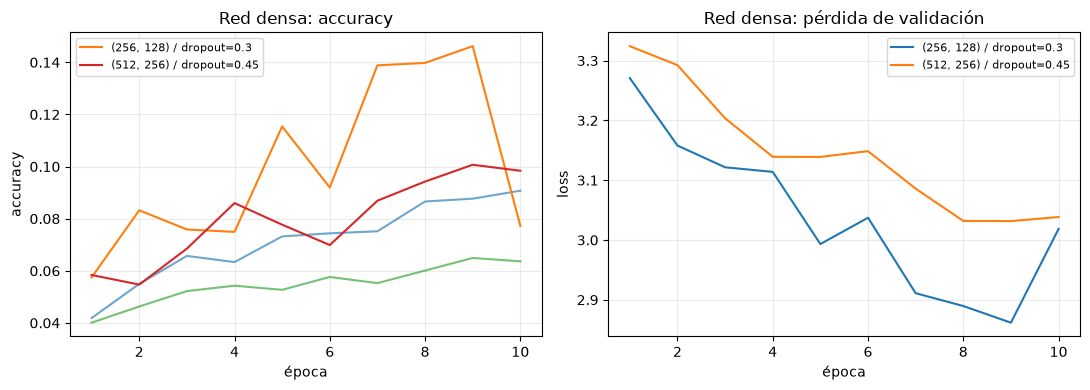

In [17]:
cfg_densa_mejor = tabla_densa.iloc[0][["ocultas", "dropout"]].to_dict()
cfg_densa_mejor["ocultas"] = tuple(cfg_densa_mejor["ocultas"])
cfg_densa_mejor["dropout"] = float(cfg_densa_mejor["dropout"])
resultado_denso = resultados_densos[(cfg_densa_mejor["ocultas"], cfg_densa_mejor["dropout"])]

y_densa, pred_densa, conf_densa = predecir_pytorch(resultado_denso.modelo, dl_te_lazy, device)
metricas_densa = metricas_clasificacion(y_densa, pred_densa)
print("mejor configuración densa:", cfg_densa_mejor)
print("métricas test:", {k: round(v, 4) for k, v in metricas_densa.items()})

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for clave, resultado in resultados_densos.items():
    etiqueta = f"{clave[0]} / dropout={clave[1]}"
    axes[0].plot(resultado.historial.epoca, resultado.historial.train_acc, alpha=.65)
    axes[0].plot(resultado.historial.epoca, resultado.historial.val_acc, label=etiqueta)
    axes[1].plot(resultado.historial.epoca, resultado.historial.val_loss, label=etiqueta)
axes[0].set(title="Red densa: accuracy", xlabel="época", ylabel="accuracy")
axes[1].set(title="Red densa: pérdida de validación", xlabel="época", ylabel="loss")
for ax in axes:
    ax.grid(alpha=.25); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


### Interpretación de la red densa

La mejor red densa, con capas `(256, 128)` y *dropout* 0.30, alcanzó **14.62%** en validación,
**13.89%** en prueba y F1 macro **0.0786**. Quedó muy por debajo de la CNN sin aumento
(91.63% en prueba), incluso sin mostrar una exactitud alta de entrenamiento. Aplanar la imagen
descarta la estructura espacial y obliga a aprender por separado relaciones entre píxeles que una
convolución comparte como bordes, dedos y contornos. La configuración más grande tampoco ayudó:
su mejor validación fue 10.07%, evidencia de que añadir parámetros no sustituye el sesgo espacial.

## 7. Algoritmo clásico: Random Forest

Se eligió Random Forest porque permite un baseline no neuronal, multiclase y no lineal; además es
robusto a escalas de variables, ofrece importancia de características y permite variar profundidad,
número de árboles y cantidad de atributos evaluados por división. Para que el costo sea razonable,
las imágenes se convierten a gris y se submuestrean de 64x64 a 16x16 (256 atributos).


In [18]:
Ftr = features_clasicas(Xtr)
Fva = features_clasicas(Xva)
Fte = features_clasicas(Xte)
print("features Random Forest:", Ftr.shape, Fva.shape, Fte.shape)

grilla_rf = [
    dict(n_estimators=200, max_depth=25, max_features="sqrt", min_samples_leaf=1),
    dict(n_estimators=300, max_depth=None, max_features="sqrt", min_samples_leaf=1),
    dict(n_estimators=250, max_depth=30, max_features=0.35, min_samples_leaf=1),
    dict(n_estimators=250, max_depth=None, max_features=0.35, min_samples_leaf=2),
]

mejor_rf, tabla_rf, mejor_cfg_rf = ajustar_random_forest(
    Ftr, ytr, Fva, yva, grilla_rf, seed=0
)
tabla_rf.reset_index(drop=True)


features Random Forest: (10150, 256) (2175, 256) (2175, 256)


{'n_estimators': 200, 'max_depth': 25, 'max_features': 'sqrt', 'min_samples_leaf': 1} -> val_acc: 0.9471


{'n_estimators': 300, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1} -> val_acc: 0.9471


{'n_estimators': 250, 'max_depth': 30, 'max_features': 0.35, 'min_samples_leaf': 1} -> val_acc: 0.949


{'n_estimators': 250, 'max_depth': None, 'max_features': 0.35, 'min_samples_leaf': 2} -> val_acc: 0.9444


,n_estimators,max_depth,max_features,min_samples_leaf,val_acc
0,250,30.0,0.35,1,0.948966
1,200,25.0,sqrt,1,0.947126
2,300,NaN,sqrt,1,0.947126
3,250,NaN,0.35,2,0.944368


mejor configuración RF: {'n_estimators': 250, 'max_depth': 30, 'max_features': 0.35, 'min_samples_leaf': 1}
métricas test: {'accuracy': 0.932, 'precision_macro': 0.9337, 'recall_macro': 0.932, 'f1_macro': 0.932}


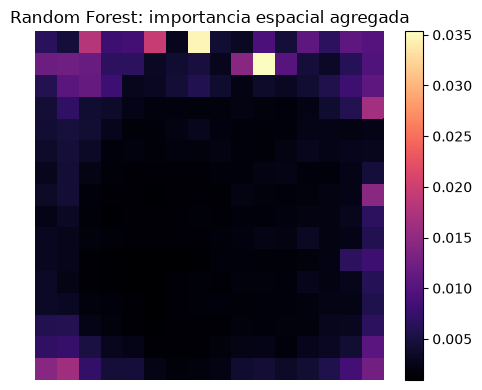

In [19]:
pred_rf = mejor_rf.predict(Fte)
metricas_rf = metricas_clasificacion(yte, pred_rf)
print("mejor configuración RF:", mejor_cfg_rf)
print("métricas test:", {k: round(v, 4) for k, v in metricas_rf.items()})

importancias = mejor_rf.feature_importances_.reshape(16, 16)
plt.figure(figsize=(5, 4))
plt.imshow(importancias, cmap="magma")
plt.title("Random Forest: importancia espacial agregada")
plt.axis("off"); plt.colorbar(fraction=.046); plt.tight_layout(); plt.show()


## 8. Image augmentation

Los aumentos se aplican **solo a train** y se generan en línea. Se usan rotaciones de hasta 12°,
traslaciones de hasta 8%, escala 0.90-1.10, *shear* leve, variaciones moderadas de brillo/contraste y
desenfoque ocasional. No se usa *flip* horizontal: una seña no es un objeto genérico y su orientación
y lateralidad forman parte del gesto; reflejarla puede crear una postura distinta o una muestra que no
corresponde a la convención con la que se etiquetó el dataset. Tampoco tienen sentido el *flip* vertical,
rotaciones extremas ni deformaciones anatómicamente imposibles.


In [20]:
dl_tr_aug = crear_dataloader(Xtr, ytr, batch_size=64, barajar=True, aumentar=True)

# Misma configuración CNN elegida antes, ahora con aumentos plausibles.
cfg_cnn_aug = {k: (int(v) if k != "dropout" else float(v)) for k, v in mejor_cfg.items()}
fijar_semilla(0)
resultado_cnn_aug = entrenar_modelo(
    CNNModular(len(clases), **cfg_cnn_aug),
    dl_tr_aug, dl_va_lazy, device, epochs=10, lr=1e-3, paciencia=3,
)
y_cnn_aug, pred_cnn_aug, _ = predecir_pytorch(resultado_cnn_aug.modelo, dl_te_lazy, device)
metricas_cnn_aug = metricas_clasificacion(y_cnn_aug, pred_cnn_aug)

# También se vuelve a entrenar el baseline fully-connected con la misma política.
fijar_semilla(0)
resultado_denso_aug = entrenar_modelo(
    RedDensa(len(clases), **cfg_densa_mejor),
    dl_tr_aug, dl_va_lazy, device, epochs=10, lr=1e-3, paciencia=3,
)
y_densa_aug, pred_densa_aug, _ = predecir_pytorch(resultado_denso_aug.modelo, dl_te_lazy, device)
metricas_densa_aug = metricas_clasificacion(y_densa_aug, pred_densa_aug)

pd.DataFrame([
    {"modelo": "CNN sin aumento", "test_acc": test_acc},
    {"modelo": "CNN con aumento", "test_acc": metricas_cnn_aug["accuracy"]},
    {"modelo": "Densa sin aumento", "test_acc": metricas_densa["accuracy"]},
    {"modelo": "Densa con aumento", "test_acc": metricas_densa_aug["accuracy"]},
])


epoca 01 | train_acc=0.0531 | val_acc=0.1743


epoca 02 | train_acc=0.2423 | val_acc=0.4437


epoca 03 | train_acc=0.4437 | val_acc=0.6326


epoca 04 | train_acc=0.5744 | val_acc=0.7113


epoca 05 | train_acc=0.6531 | val_acc=0.7995


...

epoca 07 | train_acc=0.0528 | val_acc=0.0579


epoca 08 | train_acc=0.0519 | val_acc=0.0589


epoca 09 | train_acc=0.0492 | val_acc=0.0611


epoca 10 | train_acc=0.0527 | val_acc=0.0625


,modelo,test_acc
0,CNN sin aumento,0.916322
1,CNN con aumento,0.897471
2,Densa sin aumento,0.138851
3,Densa con aumento,0.064368


### Resultado e interpretación del aumento

El aumento no mejoró esta ejecución. La CNN pasó de **91.63%** a **89.75%** en prueba
(-1.88 puntos porcentuales) y su mejor validación fue 90.25%. La red densa cayó de **13.89%** a
**6.44%**. Las transformaciones propuestas son semánticamente plausibles, pero la combinación de
rotación, traslación, escala, color y desenfoque volvió más difícil un conjunto que ya era homogéneo;
con diez épocas no compensó esa dificultad. El resultado no justifica usar *flips*: se deben ajustar
las magnitudes con capturas reales y conservar la orientación de la seña.

## 9. Comparación y selección del mejor modelo

La selección se realizó con validación; prueba se reportó después y no intervino en el ajuste. Random
Forest obtuvo la mayor validación (**94.90%**) y prueba (**93.20%, F1 macro 0.9320**), seguido por la
CNN sin aumento (**92.18%** y **91.63%, F1 0.9158**). Sin embargo, la prueba externa por persona se
usa más abajo para comprobar si ese orden se mantiene fuera de las condiciones del dataset.

In [21]:
metricas_cnn = metricas_clasificacion(yte, preds)
comparacion = pd.DataFrame([
    {"modelo": "CNN", "aumento": "no", "val_acc": float(tabla.iloc[0].val_acc), **metricas_cnn},
    {"modelo": "Red densa", "aumento": "no", "val_acc": resultado_denso.mejor_val_acc, **metricas_densa},
    {"modelo": "Random Forest", "aumento": "no aplica", "val_acc": float(tabla_rf.iloc[0].val_acc), **metricas_rf},
    {"modelo": "CNN", "aumento": "sí", "val_acc": resultado_cnn_aug.mejor_val_acc, **metricas_cnn_aug},
    {"modelo": "Red densa", "aumento": "sí", "val_acc": resultado_denso_aug.mejor_val_acc, **metricas_densa_aug},
]).sort_values("val_acc", ascending=False).reset_index(drop=True)
comparacion.round(4)


,modelo,aumento,val_acc,accuracy,precision_macro,recall_macro,f1_macro
0,Random Forest,no aplica,0.9490,0.9320,0.9337,0.9320,0.9320
1,CNN,no,0.9218,0.9163,0.9221,0.9163,0.9158
2,CNN,sí,0.9025,0.8975,0.9089,0.8975,0.8958
3,Red densa,no,0.1462,0.1389,0.1075,0.1389,0.0786
4,Red densa,sí,0.0625,0.0644,0.0108,0.0644,0.0164


In [22]:
# Se conserva el mejor modelo neuronal y también el mejor modelo global.
import joblib

candidatos_neuronales = [
    ("CNN", "no", float(tabla.iloc[0].val_acc), mejor, cfg_cnn_aug),
    ("CNN", "sí", resultado_cnn_aug.mejor_val_acc, resultado_cnn_aug.modelo, cfg_cnn_aug),
    ("RedDensa", "no", resultado_denso.mejor_val_acc, resultado_denso.modelo, cfg_densa_mejor),
    ("RedDensa", "sí", resultado_denso_aug.mejor_val_acc, resultado_denso_aug.modelo, cfg_densa_mejor),
]
arquitectura_neuronal, aumento_neuronal, val_neuronal, modelo_neuronal, cfg_neuronal = max(
    candidatos_neuronales, key=lambda fila: fila[2]
)

ruta_checkpoint = BASE / "resultados" / "mejor_modelo.pt"
guardar_checkpoint(ruta_checkpoint, modelo_neuronal, arquitectura_neuronal, cfg_neuronal, clases)

val_rf = float(tabla_rf.iloc[0].val_acc)
if val_rf >= val_neuronal:
    arquitectura_final = "RandomForest"
    aumento_final = "no aplica"
    val_final = val_rf
    modelo_final = mejor_rf
    cfg_final = mejor_cfg_rf
    ruta_modelo_final = BASE / "resultados" / "mejor_modelo_rf.joblib"
    ruta_modelo_final.parent.mkdir(exist_ok=True)
    joblib.dump(modelo_final, ruta_modelo_final)
else:
    arquitectura_final = arquitectura_neuronal
    aumento_final = aumento_neuronal
    val_final = val_neuronal
    modelo_final = modelo_neuronal
    cfg_final = cfg_neuronal
    ruta_modelo_final = ruta_checkpoint

print("mejor global:", arquitectura_final, "val_acc:", round(val_final, 4))
print("modelo guardado:", ruta_modelo_final)
print("mejor neuronal:", arquitectura_neuronal, "aumento:", aumento_neuronal,
      "val_acc:", round(val_neuronal, 4))

mejor global: RandomForest val_acc: 0.949
modelo guardado: C:\Users\VICTUS\Desktop\8vo Semestre\Data\Lab 3\laboratorio3_ds\resultados\mejor_modelo_rf.joblib
mejor neuronal: CNN aumento: no val_acc: 0.9218


## 10. Prueba con señas de los integrantes

Se evaluaron 24 fotografías externas: dos tomas de seis letras distintas (`A, B, L, U, V, W`) por
cada integrante. Se comparó el mejor modelo global, Random Forest, contra la mejor alternativa
neuronal, la CNN sin aumento. Esta prueba cambia persona, teléfono, fondo, distancia e iluminación y
por ello mide generalización de manera más realista que el split aleatorio interno.

In [23]:
DIR_FOTOS = BASE / "data" / "propias"
resultados_rf = evaluar_fotos_random_forest(mejor_rf, clases, DIR_FOTOS)
resultados_cnn = evaluar_fotos_propias(modelo_neuronal, clases, DIR_FOTOS, device)

if resultados_rf.empty or resultados_cnn.empty:
    print("No se encontraron fotografías propias en", DIR_FOTOS)
else:
    resultados_rf = resultados_rf.assign(modelo="Random Forest")
    resultados_cnn = resultados_cnn.assign(modelo="CNN")
    resultados_fotos = pd.concat([resultados_rf, resultados_cnn], ignore_index=True)
    cobertura = resultados_fotos.groupby(["modelo", "integrante"])["real"].nunique()
    print("letras distintas por modelo e integrante:", cobertura, sep=chr(10))
    resumen_fotos = (
        resultados_fotos.groupby(["modelo", "integrante"])
        .agg(fotos=("acierto", "size"), letras=("real", "nunique"), accuracy=("acierto", "mean"))
        .reset_index()
    )
    display(resultados_fotos[["modelo", "integrante", "real", "predicha", "confianza", "acierto"]])
    display(resumen_fotos)
    (BASE / "resultados").mkdir(exist_ok=True)
    resultados_rf.to_csv(BASE / "resultados" / "fotos_propias.csv", index=False)
    resultados_fotos.to_csv(BASE / "resultados" / "fotos_propias_comparacion.csv", index=False)

letras distintas por modelo e integrante:
modelo         integrante
CNN            Diego         6
               Ihan          6
Random Forest  Diego         6
               Ihan          6
Name: real, dtype: int64


,modelo,integrante,real,predicha,confianza,acierto
0,Random Forest,Diego,A,nothing,0.396000,False
1,Random Forest,Diego,A,nothing,0.416000,False
2,Random Forest,Diego,B,nothing,0.236000,False
3,Random Forest,Diego,B,nothing,0.212000,False
4,Random Forest,Diego,L,nothing,0.376000,False
5,Random Forest,Diego,L,nothing,0.252000,False
6,Random Forest,Diego,U,nothing,0.228000,False
7,Random Forest,Diego,U,nothing,0.344000,False
8,Random Forest,Diego,V,nothing,0.184000,False
9,Random Forest,Diego,V,nothing,0.220000,False


,modelo,integrante,fotos,letras,accuracy
0,CNN,Diego,12,6,0.416667
1,CNN,Ihan,12,6,0.333333
2,Random Forest,Diego,12,6,0.000000
3,Random Forest,Ihan,12,6,0.000000


### Discusión de la prueba externa

Random Forest, pese a liderar la prueba interna con 93.20%, predijo `nothing` para las 24 fotografías
y obtuvo **0% en ambos integrantes**. Sus confianzas (18.4%-60.8%) muestran que el descriptor gris
16x16 aprendió regularidades de fondo, escala y encuadre que no se trasladaron a los teléfonos del
grupo. La CNN generalizó mejor, aunque todavía de forma insuficiente: Diego obtuvo **5/12 (41.67%)**
e Ihan **4/12 (33.33%)**. Reconoció sobre todo U y W; aparecieron V→U/W, A→S/Y, B→M/R y L→S/T.

El error A→Y de Diego llegó a 96.08% de confianza y A→S de Ihan a 88.47%, lo que revela mala
calibración fuera de dominio. Por tanto, Random Forest es el mejor en el split interno, pero la CNN es
la candidata más razonable para continuar: conserva estructura espacial y tuvo alguna transferencia a
usuarios nuevos. Para un producto se necesita segmentación de mano, datos diversos, evaluación por
persona y una salida de rechazo cuando la confianza no sea fiable.

## 11. Accesibilidad, sesgo y paso a producto

El dataset es grande y balanceado por etiqueta, pero balance de clases **no equivale a representación
de usuarios**. Las imágenes parecen capturadas en condiciones relativamente homogéneas y no traen
metadatos de persona. Por ello no se puede auditar desempeño por tono de piel, edad, discapacidad
motora, mano dominante, tamaño de mano, cámara, fondo, país o calidad de iluminación. Un split aleatorio
también puede colocar imágenes casi idénticas de la misma sesión en train y test, inflando la métrica.

Para SignBridge haría falta:

1. recolectar datos consentidos de muchas personas y dispositivos, con diversidad de tonos de piel,
   edades, anatomías, lateralidad, fondos e iluminación;
2. dividir por persona o sesión, mantener un test externo y reportar métricas por subgrupo con intervalos
   de confianza;
3. usar video para J/Z y para el contexto temporal, detección/segmentación de mano y una clase de rechazo
   cuando la confianza sea insuficiente;
4. probar con usuarios sordos y especialistas en ASL, documentar usos no previstos, proteger las imágenes
   biométricas y permitir corrección humana;
5. monitorear errores después del despliegue. Una recomendación concreta es hacer un piloto con al menos
   20 firmantes, separar completamente 5 para prueba externa y fijar un umbral de confianza que muestre
   “no estoy seguro” en vez de emitir una letra incorrecta.


## 12. Conclusiones

- Se procesaron 500 ejemplos de cada una de las 29 clases y se construyó un split reproducible
  70/15/15 de 10,150/2,175/2,175 imágenes.
- Random Forest fue el mejor en datos internos: 94.90% en validación y 93.20% en prueba. La mejor CNN
  obtuvo 92.18% y 91.63%, respectivamente; la red densa solo alcanzó 13.89% en prueba.
- El aumento moderado redujo la CNN a 89.75%, por lo que debe recalibrarse con variación real y nunca
  introducir reflejos o deformaciones que cambien el significado de la seña.
- Las confusiones internas más frecuentes incluyeron U→R (18), U→V (9), R→K (8), N→M (7) y X→S
  (7), coherentes en parte con similitud de dedos y orientación.
- La evaluación externa cambió la conclusión práctica: Random Forest obtuvo 0% y siempre predijo
  `nothing`, mientras la CNN logró 41.67% para Diego y 33.33% para Ihan. La métrica interna estaba
  inflada por condiciones homogéneas y no demuestra accesibilidad ni generalización.
- Para SignBridge se requieren datos consentidos de múltiples usuarios, división por persona/sesión,
  segmentación de mano, video para J/Z, métricas por subgrupo y rechazo por baja confianza.